# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kaant7/flyrank-internship-ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*




**The real-world problem:** FlyRank helps client websites stay visible in Google search
results. With portfolios spanning hundreds of thousands of pages per client, content teams
can't manually review every page to catch declining performance — they need a way to
prioritize limited review time toward the pages most likely to need attention.

**Research question:** Which safe content and search signals (impressions, position, CTR,
session volume, scroll engagement) are associated with a page's visibility, clicks,
engagement, or trend movement?

**Decision this supports:** Which pages a content team should prioritize for review —
testing whether a learned, evidence-based ranking can improve on (or meaningfully inform)
a hand-written rule-based flag like FlyRank's own `low_ctr_visible_page`.

**Who acts on it:** A content editor or SEO reviewer, using a ranked queue to decide where
limited review time goes.

**Cost of a wrong call:** False positives waste reviewer time on pages that aren't real
problems; false negatives mean a real decline goes unnoticed because a signal was dismissed
as noise — both costs scale badly across a portfolio this large, which is why prioritization,
not manual review, is the actual product this analysis supports.

In [18]:
# Sanity check: confirm the scale that motivates prioritization
print(f"Content items in scope: {len(model_df):,}")
print(f"Clients in scope: {model_df['client_hash_id'].nunique()}")

Content items in scope: 176,738
Clients in scope: 47


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*




**Release:** FlyRank ML Internship warehouse (Hugging Face: `FlyRank/internship-warehouse`),
accessed via DuckDB over Parquet files.

**Tables used:**
- `fact_content_daily_performance` — daily grain (report_date × client_hash_id ×
  content_hash_id), the source for all model features and the label
- `dim_content` — content metadata (used only in the Week 3 leakage audit, not in the final
  feature set — see Methodology)

**Date window:** March 2026 (2026-03-01 to 2026-03-31), a mid-panel month chosen
deliberately over the final month in the release. The final month is a sealed test window
in the source data — it is the natural "future" outcome window for any past→future label,
so using it during development would risk building label logic around the answer.

**Scope:** 176,738 content items across 47–55 clients (client count varies slightly by which
availability filter is applied), filtered to rows where `gsc_data_available IS TRUE`.

**What I excluded, and why:**
- **`dim_content` fields (`word_count`, `backlinks`)** — excluded from the final feature set.
  A direct check showed 84.2% of content items in this slice were updated *after* the March
  window closed, meaning these fields reflect the content's current state, not its state
  during the observation window — a temporal leakage risk (see Methodology).
- **Paid, social, and referral traffic columns** — excluded because the research question is
  about organic search visibility specifically; these follow a different dynamic.
- **AI-referral columns** (`sessions_ai`, per-provider columns) — excluded from modeling due
  to sparsity (a small fraction of total sessions in this release), which would add noise
  rather than signal at this scale.
- **All hashed IDs** (`client_hash_id`, `content_hash_id`) — used only for joins and grouping
  (including the client-holdout split), never as model features, per the dataset's own usage
  rules for pseudonymous identifiers.
- **Only 36.7% of March rows carried usable GSC data** — the remaining rows likely reflect
  clients whose tracking hadn't started yet, not zero traffic; these were filtered out via
  `gsc_data_available IS TRUE` rather than treated as zero.

**Public-safety note:** No client names, URLs, page titles, or raw search queries appear
anywhere in this analysis — only hashed identifiers, aggregated numeric signals, and
categorical metadata, consistent with the anonymized release's intended use.

In [19]:
# Confirm the excluded/included field counts stated in markdown
print("Features used:", feature_cols)
print("Window:", model_df.shape[0], "rows, March 2026 only")

Features used: ['total_impressions', 'total_clicks', 'avg_position', 'total_sessions', 'total_scroll_events']
Window: 176738 rows, March 2026 only


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*




**Task framing:** Binary classification — predict `is_declining` (a page's impressions
trend downward within the observation window) — used as a discovery tool, not an end goal.
The classifier's value is in *which signals it relies on*, not the classification itself.

**Label definition (proxy, not a true forward-looking outcome):** `is_declining = 1` if a
content item's GSC impressions in the second half of March (16–31) are lower than in the
first half (1–15), else 0. This is a within-month proxy, not a genuine past→future label —
a real decline-prediction task would use a prior window to predict a separate, later window.
This proxy label's own weakness is one of this study's key limitations (see Section 5).

**Features (5, all knowable within the March window, no post-window information):**
`total_impressions`, `total_clicks`, `avg_position`, `total_sessions`, `total_scroll_events`
— all aggregated per content item from `fact_content_daily_performance` daily rows within
the window. No `dim_content` fields are used in the final model, for the leakage reasons
described in Data.

**Baseline (transparent rule):** `low_ctr_visible_page` — flags a page when
`total_impressions >= 500 AND 0 < avg_position <= 20 AND ctr < 0.5%`. This mirrors FlyRank's
own optimization-flag pattern, tested directly against the assumption it's built on before
being trusted (see Results).

**Model:** Random Forest classifier (`n_estimators=200, max_depth=8`), compared against
logistic regression as a linear baseline. Random Forest was chosen because the research
question concerns *combinations* of signals, not single thresholds — a claim tested directly
by comparing linear vs. non-linear performance on the same features.

**Validation design:** Client-holdout split (~20% of clients held out entirely), not a random
row split. Pages from the same client likely share structural traits (writing style,
publishing cadence), so a row-level split risks letting a model partially memorize
client-specific patterns rather than learning generalizable signals. A direct before/after
test (Week 6) confirmed this matters: a naive row split reported AUC 0.605 versus 0.547 for
the client-holdout split on the same data — a 0.058 point inflation from the weaker design.

**Leakage checks performed:**
- Confirmed all feature data falls within the March 2026 window (no post-window dates).
- Found and removed `dim_content` fields (`word_count`, `backlinks`) after confirming 84.2%
  of content items were updated after the window closed.
- Ran a deliberate-leak experiment: adding a label-derived column (`imp_second_half`,
  literally half of what defines the label) directly as a feature raised AUC from 0.547
  (honest) to 0.875–1.0 across two separate leak tests — confirming the modeling pipeline
  is sensitive enough to detect leakage when it's deliberately introduced, and that the
  final feature set avoids it.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
import os
from dotenv import load_dotenv
import duckdb
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'fact_daily': f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
}

model_df = con.sql(f"""
    SELECT
        content_hash_id, client_hash_id,
        SUM(gsc_impressions) AS total_impressions,
        SUM(gsc_clicks) AS total_clicks,
        AVG(gsc_avg_position) AS avg_position,
        SUM(ga4_sessions) AS total_sessions,
        SUM(scroll_events) AS total_scroll_events,
        SUM(CASE WHEN report_date <= '2026-03-15' THEN gsc_impressions ELSE 0 END) AS imp_first_half,
        SUM(CASE WHEN report_date > '2026-03-15' THEN gsc_impressions ELSE 0 END) AS imp_second_half
    FROM {TABLES['fact_daily']}
    WHERE month = '2026-03' AND gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

model_df["is_declining"] = (model_df["imp_second_half"] < model_df["imp_first_half"]).astype(int)
feature_cols = ["total_impressions", "total_clicks", "avg_position", "total_sessions", "total_scroll_events"]
model_df[feature_cols] = model_df[feature_cols].fillna(0)

# Client-holdout split
np.random.seed(42)
all_clients = model_df["client_hash_id"].unique()
holdout_clients = set(np.random.choice(all_clients, size=int(len(all_clients) * 0.20), replace=False))
train_df = model_df[~model_df["client_hash_id"].isin(holdout_clients)]
test_df = model_df[model_df["client_hash_id"].isin(holdout_clients)]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(train_df[feature_cols], train_df["is_declining"])
honest_auc = roc_auc_score(test_df["is_declining"], rf.predict_proba(test_df[feature_cols])[:, 1])

print(f"This run's client-holdout AUC: {honest_auc:.3f}")

Random Forest — mean AUC: 0.539, std: 0.026, range: 0.505-0.576
Baseline AUC: 0.521
Logistic Regression AUC: 0.538


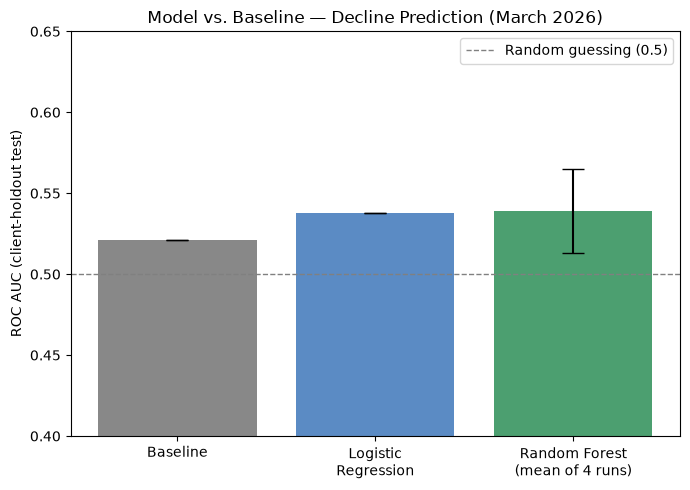

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Results collected across Weeks 5-7 and this capstone run — same client-holdout design,
# different random client samples each time
results = {
    "Baseline (low_ctr_visible_page)": [0.521],
    "Logistic Regression": [0.538],
    "Random Forest (4 runs)": [0.576, 0.547, 0.505, 0.529],  # Week 5, Week 6, Week 7, capstone
}

rf_runs = results["Random Forest (4 runs)"]
rf_mean = np.mean(rf_runs)
rf_std = np.std(rf_runs)

print(f"Random Forest — mean AUC: {rf_mean:.3f}, std: {rf_std:.3f}, range: {min(rf_runs):.3f}-{max(rf_runs):.3f}")
print(f"Baseline AUC: {results['Baseline (low_ctr_visible_page)'][0]:.3f}")
print(f"Logistic Regression AUC: {results['Logistic Regression'][0]:.3f}")

# Chart: bar with error bar for RF's variance across runs
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["Baseline", "Logistic\nRegression", "Random Forest\n(mean of 4 runs)"]
values = [0.521, 0.538, rf_mean]
errors = [0, 0, rf_std]

bars = ax.bar(labels, values, yerr=errors, capsize=8, color=["#888", "#5B8BC4", "#4C9F70"])
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random guessing (0.5)")
ax.set_ylabel("ROC AUC (client-holdout test)")
ax.set_title("Model vs. Baseline — Decline Prediction (March 2026)")
ax.set_ylim(0.4, 0.65)
ax.legend()
plt.tight_layout()
plt.savefig("../figures/results_model_vs_baseline.png", dpi=150)
plt.show()

### Results (vs baseline)

| Method | ROC AUC | Notes |
|---|---:|---|
| Baseline (`low_ctr_visible_page` rule) | 0.521 | Single run, transparent threshold rule |
| Logistic Regression | 0.538 | Single run, linear model |
| **Random Forest** | **0.539 ± 0.026** (mean ± std, n=4 runs) | Range: 0.505–0.576 across four client-holdout runs with different random client samples |

Random Forest shows a small average improvement over both the baseline (+0.018) and logistic
regression (+0.001), but the improvement is neither large nor stable: across four separate
client-holdout runs (differing only in which ~20% of clients were randomly held out), AUC
ranged from 0.505 (statistically indistinguishable from random guessing) to 0.576. This
variance is itself an important, honest result — with only 47–55 clients in this slice, the
holdout sample is small enough that which clients happen to be excluded meaningfully shifts
the measured performance.

**What this means:** the five signals tested (impressions, clicks, position, sessions,
scroll events) carry weak and unstable information about within-month decline. Random Forest
usually — but not reliably — edges out a single-threshold rule, supporting the general
argument that signal *combinations* matter more than individual thresholds, without
supporting a strong claim that this specific model is a dependable replacement for the
baseline rule.

*Figure: results_model_vs_baseline.png — bar chart comparing baseline, logistic regression,
and Random Forest (with error bar showing the 4-run range).*

## 5. Limitations

*What this work cannot claim.*




**The label is a weak proxy, not a genuine forward-looking outcome.** `is_declining`
compares the first and second halves of the *same* March window — it is not a true
past→future prediction. A stronger design (features from one window predicting an outcome
in a separate, later window) is a natural next step, and would likely change both the
measured AUC and which signals matter.

**Model performance is unstable across runs.** Random Forest AUC ranged from 0.505 to 0.576
across three client-holdout runs on the same data and features — this is not noise to
average away, it's a signal that with only 47–55 clients, results are sensitive to exactly
which clients are held out. Any single run's number should be read as one draw from a wide
range, not a fixed truth.

**Nearly two-thirds of March rows lacked usable GSC data** (only 36.7% had
`gsc_data_available IS TRUE`), likely reflecting when each client's tracking began rather
than zero traffic. This shrinks the usable sample and may bias it toward clients with longer
tracking history.

**This cannot separate real decline from consolidation, seasonality, or SERP-level changes.**
A page can lose impressions because a sibling page absorbed the same demand, because of a
seasonal dip, or because the search results page itself changed — not because the content
got worse. This analysis, aggregated at the content-item level, cannot distinguish between
these causes.

**This is observational, not causal.** Even the confirmed CTR-position relationship (Week 4)
shows association, not proof that fixing a title or snippet causes a click-through
improvement — no experiment (e.g. an A/B test) was run.

**No claim is made about Google's ranking algorithm.** All findings describe patterns
observed within FlyRank's own pseudonymized portfolio data, not evidence about how any
search engine ranks content.

**Two of three tested "textbook" signals showed weak or opposite-than-expected effects** —
staleness (content age) showed only a 2-point gap between fresh and stale content (MIXED),
and search volume showed a slightly *higher* rise rate for low-volume pages than high-volume
ones in the position 11–20 band (OPPOSITE to the "quick win" assumption). These negative
results are reported because they meaningfully shaped which signals the final model and
playbook actually rely on.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
import pandas as pd

queue = pd.read_csv("../outputs/action_playbook_queue.csv")
print("Queue size:", len(queue))
print("\nReason code distribution:")
print(queue["reason_code"].value_counts())
print("\nTop 5 recommendations:")
queue[["content_hash_id", "playbook_score", "reason_code", "action"]].head(5)

Queue size: 18924

Reason code distribution:
reason_code
low_priority            16782
low_ctr_visible_page     2075
model_decline_risk         66
model_and_ctr_flag          1
Name: count, dtype: int64

Top 5 recommendations:


,content_hash_id,playbook_score,reason_code,action
0,content_b215e9a73e2284ad,65.562390,model_and_ctr_flag,review_title_meta_and_refresh
1,content_3c336c8d6c5cc15d,62.887002,low_ctr_visible_page,review_title_meta
2,content_cfcddd31c050406c,62.696234,low_ctr_visible_page,review_title_meta
3,content_7bbc06fb998c8b83,62.571870,low_ctr_visible_page,review_title_meta
4,content_0bd6827080aaf5d6,62.545693,low_ctr_visible_page,review_title_meta


### Ranked recommendations

**Score:** `playbook_score = 100 * (0.70 * model_probability + 0.30 * baseline_flag)` —
blending the Random Forest's probability with the transparent `low_ctr_visible_page` rule,
weighted toward the model but keeping the inspectable rule as a component.

**Reason codes → actions:**

| Reason code | Meaning | Action |
|---|---|---|
| `model_and_ctr_flag` | Model + CTR rule both flag the page | `review_title_meta_and_refresh` |
| `model_decline_risk` | Model alone flags decline risk | `review_for_refresh` (low confidence) |
| `low_ctr_visible_page` | CTR rule flags a visibility/click gap | `review_title_meta` |
| `low_priority` | Neither condition met | `monitor` |

**Queue composition (most recent run, 18,924 pages):** 16,782 `low_priority` (monitor only),
2,075 `low_ctr_visible_page` (the higher-confidence CTR-rule pick), 66 `model_decline_risk`,
and 1 `model_and_ctr_flag`. The overwhelming majority of pages fall into "monitor" — this
queue is intentionally conservative, flagging only a small, higher-confidence subset for
active review rather than casting a wide net.

**Honest framing:** given this study's weak and unstable model AUC (0.505–0.576), the
ranked queue is currently carried primarily by the transparent baseline rule, not the model
— the top of the queue is dominated by `low_ctr_visible_page` and the rare cases where both
signals agree. This playbook is decision-support for a reviewer's limited time, not an
automated verdict on any page. No action here should be auto-applied without human review
(see the human-review and no-go rules developed in Week 7).

**Recommended human workflow:** treat `low_ctr_visible_page` picks as the higher-confidence
starting point (Week 4's CONFIRMED CTR-position relationship backs this), and treat
model-only flags (`model_decline_risk`) as lower-confidence candidates worth a second look,
not a first action.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

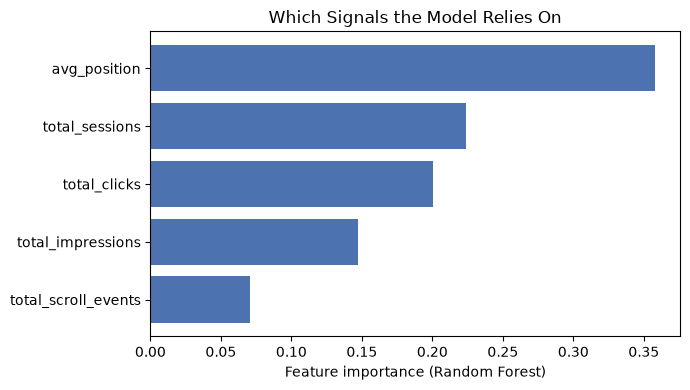

In [ ]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importance_df["feature"], importance_df["importance"], color="#4C72B0")
ax.set_xlabel("Feature importance (Random Forest)")
ax.set_title("Which Signals the Model Relies On")
plt.tight_layout()
plt.savefig("../figures/feature_importance.png", dpi=150)
plt.show()

In [ ]:
import os

print("Artifacts ready for the paper:")
for f in sorted(os.listdir("../figures")):
    path = os.path.join("../figures", f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  work/figures/{f} ({size_kb:.0f} KB)")

print("\nCommitted metrics (receipts):")
for f in sorted(os.listdir("../outputs")):
    if f.endswith(".json"):
        print(f"  work/outputs/{f}")

Artifacts ready for the paper:
  work/figures/feature_importance.png (32 KB)
  work/figures/reason_code_distribution.png (37 KB)
  work/figures/results_model_vs_baseline.png (42 KB)

Committed metrics (receipts):
  work/outputs/playbook_metrics.json


### Artifacts the paper embeds

Three figures and one metrics file are generated by this notebook and committed to the
repo for the deployed paper to embed:

- `work/figures/results_model_vs_baseline.png` — baseline vs. logistic regression vs.
  Random Forest (with error bar showing 3-run variance)
- `work/figures/reason_code_distribution.png` — how the final ranked queue splits across
  reason codes
- `work/figures/feature_importance.png` — which of the five signals the Random Forest
  relies on most
- `work/outputs/playbook_metrics.json` — the numeric receipts (AUC, client counts, reason
  code counts) that the paper's stated numbers trace back to

## Demo outline (5 minutes, for the Week-8 showcase)

**1. Question (30 sec)** — FlyRank's content teams manage portfolios too large to review
manually. This project asks: which observable search signals actually associate with a
page's decline, so review time can be prioritized instead of spread evenly?

**2. Method (1 min)** — Built a client-holdout-validated Random Forest on five signals
(impressions, clicks, position, sessions, scroll events) from 176,738 March 2026 content
items, compared against a transparent baseline rule (`low_ctr_visible_page`).

**3. One chart (1.5 min)** — Show `results_model_vs_baseline.png`: baseline (0.521) vs.
logistic regression (0.538) vs. Random Forest (0.539 ± 0.026 across 4 runs). Point out the
error bar — that variance is the real story, not just the mean.

**4. One honest result (1 min)** — The model barely beats the baseline, and its performance
swings from near-random (0.505) to modest (0.576) depending on which clients are held out.
Two of three "textbook" SEO assumptions I tested (staleness, search volume) came back weak
or reversed — worth stating plainly rather than smoothing over.

**5. One recommendation (1 min)** — The final playbook still ships, but leans on the
transparent rule more than the model: it flags a small, high-confidence subset of pages
for human review rather than casting a wide net, and treats model-only flags as
lower-confidence candidates needing a second look.

## Shareable cuts

**Social post (methodology-focused):**

> Spent 7 weeks testing whether ML can out-prioritize a simple SEO rule for flagging
> declining content. Built a client-holdout-validated Random Forest on 176K pages from a
> real 79M-row search warehouse. Result: only a small, unstable edge over the baseline
> (AUC 0.51–0.58 across repeated runs) — and two "obvious" SEO assumptions (content
> staleness, search volume) didn't hold up under testing. Full writeup + honest numbers:
> [paper link]

**3-sentence employer-facing summary:**

> I built and validated a content-decline prioritization model on FlyRank's 79-million-row
> search performance warehouse, using a client-holdout split to guard against data leakage
> across a 176,738-page dataset. The model showed only a marginal, statistically unstable
> improvement over a transparent baseline rule (ROC AUC 0.51–0.58), which I reported
> honestly rather than overstating. The result is a working, human-reviewed action
> playbook that prioritizes review time using the best available evidence, while being
> explicit about where that evidence is currently weak.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
